<a href="https://colab.research.google.com/github/jamoffl3/Crytocurrency-Volatility-Tracker/blob/main/weeek-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 6: Feature Engineering with Visualizations**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

#**Dataset**

In [3]:
finance_df = pd.read_csv("Bitcoin_12_4_2025-2_5_2026_historical_data_coinmarketcap.csv", sep=";")
tweets_df = pd.read_csv("crypto_10k_tweets_(2021_2022Nov).csv", engine="python", encoding="latin1", on_bad_lines="skip")

print("Data Loaded")

Data Loaded


#**Data Cleaning**

In [4]:
finance_df["timeOpen"] = pd.to_datetime(finance_df["timeOpen"], errors="coerce")

numeric_cols = ["open","high","low","close","volume","marketCap","circulatingSupply"]

for col in numeric_cols:
    finance_df[col] = (
        finance_df[col]
        .astype(str)
        .str.replace(",", "", regex=True)
        .str.replace("$", "", regex=True)
        .str.replace("%", "", regex=True)
    )
    finance_df[col] = pd.to_numeric(finance_df[col], errors="coerce")

finance_df = finance_df.dropna()

finance_df.head()

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,circulatingSupply,timestamp
0,2026-02-03 00:00:00+00:00,2026-02-03T23:59:59.999Z,2026-02-03T01:03:00.000Z,2026-02-03T19:03:00.000Z,2781,78693.509356,79118.848041,72897.144447,75633.549920,6.824911e+10,1.511490e+12,19982656,2026-02-03T23:59:59.999Z
1,2026-02-02 00:00:00+00:00,2026-02-02T23:59:59.999Z,2026-02-02T15:41:00.000Z,2026-02-02T03:41:00.000Z,2781,76968.872934,79258.608481,74551.333199,78688.764338,7.514059e+10,1.572505e+12,19982656,2026-02-02T23:59:59.999Z
2,2026-02-01 00:00:00+00:00,2026-02-01T23:59:59.999Z,2026-02-01T00:17:00.000Z,2026-02-01T23:10:00.000Z,2781,78626.126926,79322.612509,75698.901206,76974.442908,5.337251e+10,1.538043e+12,19982656,2026-02-01T23:59:59.999Z
3,2026-01-31 00:00:00+00:00,2026-01-31T23:59:59.999Z,2026-01-31T00:42:00.000Z,2026-01-31T18:45:00.000Z,2781,84126.498154,84136.921181,75815.882843,78621.114028,7.047926e+10,1.571159e+12,19982656,2026-01-31T23:59:59.999Z
4,2026-01-30 00:00:00+00:00,2026-01-30T23:59:59.999Z,2026-01-30T00:03:00.000Z,2026-01-30T02:32:00.000Z,2781,84562.728086,84602.163483,81071.472849,84128.658762,7.208382e+10,1.681056e+12,19982475,2026-01-30T23:59:59.999Z


## **1. Feature Scaling (Standardization)**

In [5]:
scaler = StandardScaler()
scaled = scaler.fit_transform(finance_df[numeric_cols])
scaled_df = pd.DataFrame(scaled, columns=numeric_cols)

scaled_df.head()

,open,high,low,close,volume,marketCap,circulatingSupply
0,-1.861953,-1.963931,-2.175197,-2.106591,0.678578,-2.073119,1.679377
1,-2.008203,-1.952024,-2.036939,-1.848847,0.970215,-1.815003,1.679377
2,-1.867667,-1.946571,-1.941024,-1.993470,0.049022,-1.960793,1.679377
3,-1.401231,-1.536402,-1.931246,-1.854554,0.772954,-1.820699,1.679377
4,-1.364238,-1.496764,-1.491979,-1.389927,0.840857,-1.355797,1.675911


<Figure size 640x480 with 0 Axes>

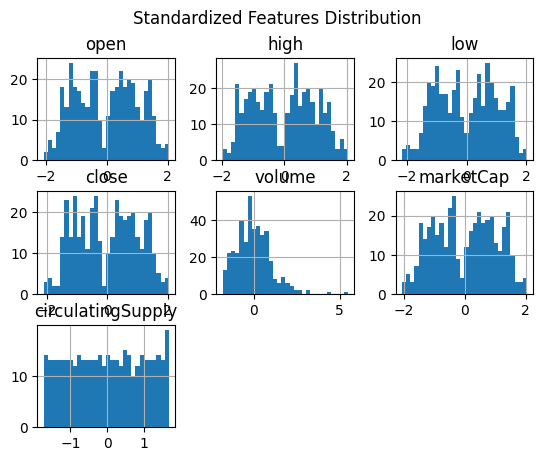

In [6]:
plt.figure()
scaled_df.hist(bins=30)
plt.suptitle("Standardized Features Distribution")
plt.show()

## **2. Normalization (Min-Max Scaling)**

In [7]:
minmax = MinMaxScaler()
normalized = minmax.fit_transform(finance_df[numeric_cols])
norm_df = pd.DataFrame(normalized, columns=numeric_cols)

norm_df.head()

,open,high,low,close,volume,marketCap,circulatingSupply
0,0.049918,0.000000,0.000000,0.000000,0.339684,0.000000,1.000000
1,0.014343,0.002969,0.032887,0.062200,0.379778,0.062589,1.000000
2,0.048528,0.004328,0.055702,0.027299,0.253133,0.027238,1.000000
3,0.161988,0.106588,0.058028,0.060823,0.352658,0.061208,1.000000
4,0.170986,0.116470,0.162515,0.172950,0.361993,0.173940,0.998982


<Figure size 640x480 with 0 Axes>

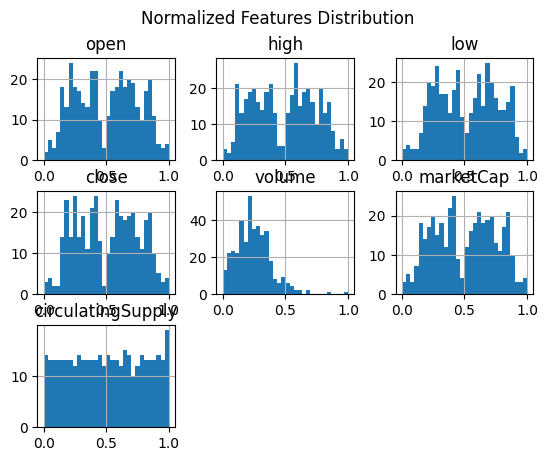

In [8]:
plt.figure()
norm_df.hist(bins=30)
plt.suptitle("Normalized Features Distribution")
plt.show()

## **3. Handling Skewness**

In [9]:
skew_before = finance_df[numeric_cols].skew()

log_data = np.log1p(finance_df[numeric_cols])
skew_after = log_data.skew()

print("Before:\n", skew_before)
print("\nAfter Log Transform:\n", skew_after)

Before:
 open                 0.003938
high                 0.018785
low                 -0.022492
close               -0.007149
volume               0.981099
marketCap            0.003163
circulatingSupply   -0.002623
dtype: float64

After Log Transform:
 open                -0.147600
high                -0.124736
low                 -0.191331
close               -0.162350
volume              -0.593828
marketCap           -0.154282
circulatingSupply   -0.005752
dtype: float64


<Figure size 640x480 with 0 Axes>

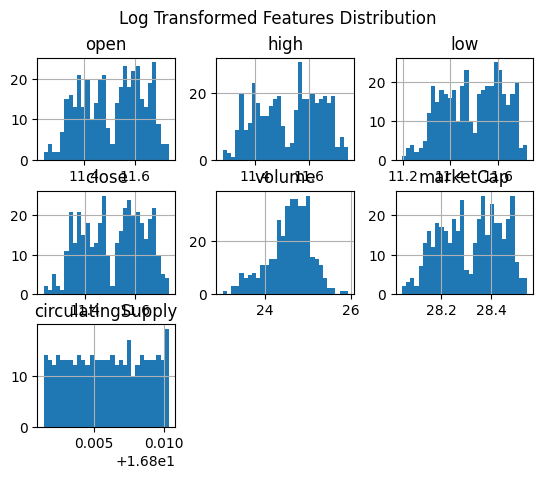

In [10]:
plt.figure()
log_data.hist(bins=30)
plt.suptitle("Log Transformed Features Distribution")
plt.show()

## **4. Correlation Heatmap (After Scaling)**

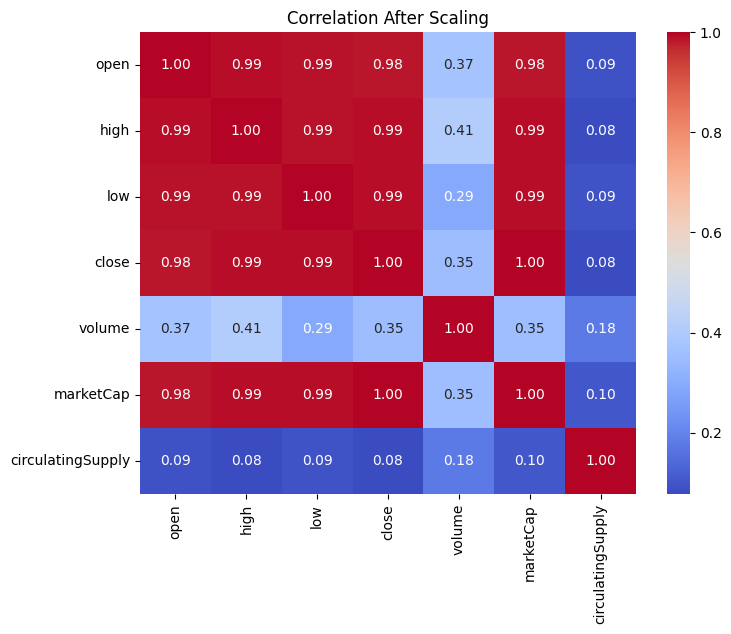

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(scaled_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation After Scaling")
plt.show()

## **5. Tweet Feature Engineering**

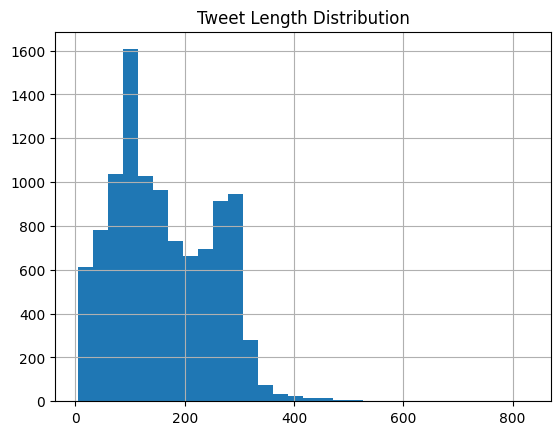

In [12]:
tweets_df["tweet_length"] = tweets_df["Content"].astype(str).apply(len)

plt.figure()
tweets_df["tweet_length"].hist(bins=30)
plt.title("Tweet Length Distribution")
plt.show()

In [13]:
encoder = LabelEncoder()
tweets_df["length_category"] = encoder.fit_transform(
    pd.cut(tweets_df["tweet_length"], bins=5, labels=False)
)

tweets_df[["tweet_length","length_category"]].head()

,tweet_length,length_category
0,140,0
1,302,1
2,101,0
3,56,0
4,223,1
